# Assignment 1

Bài toán phân loại (classification) trên ba loại dữ liệu: ảnh, văn bản và đa phương thức (ảnh + văn bản).

Import thư viện

In [1]:
import os
import re
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'   Using device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

   Using device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB


# 2. Dataset Loading & Exploratory Data Analysis

In [2]:
!pip install datasets
!pip install wordcloud
!pip install "transformers<5.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("imdb")
print(type(dataset['train']))
df = pd.concat([pd.DataFrame(dataset['train']), pd.DataFrame(dataset['test'])])

# train_df.to_csv("imdb_train.csv", index=False)
# print("\nĐã lưu tập train vào file 'imdb_train.csv'")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

<class 'datasets.arrow_dataset.Dataset'>


# EDA

In [4]:
print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
# print(f'Null values   :\n{df.isnull().sum()}')
print(df.describe())
print(df.info())
print(df['label'].value_counts())
df.head()

Dataset shape : (50000, 2)
Columns       : ['text', 'label']
              label
count  50000.000000
mean       0.500000
std        0.500005
min        0.000000
25%        0.000000
50%        0.500000
75%        1.000000
max        1.000000
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    50000 non-null  object
 1   label   50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ MB
None
label
0    25000
1    25000
Name: count, dtype: int64


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


Note:

- Label 0: Negative (Tiêu cực/Chê). Bài đánh giá có nội dung không hài lòng về bộ phim.
- Label 1: Positive (Tích cực/Khen). Bài đánh giá có nội dung yêu thích hoặc đánh giá cao bộ phim.

##  Class distribution

label
0    25000
1    25000
Name: count, dtype: int64


([<matplotlib.patches.Wedge at 0x7f654f9253a0>,
 [Text(-0.7392056177253551, -0.8809512215345844, 'Positive'),
  Text(0.7070663702780942, 0.8426488877472997, 'Negative')],
 [Text(-0.4178118708882441, -0.49792895130215636, '50.0%'),
  Text(0.38567256560623314, 0.4596266660439816, '50.0%')])

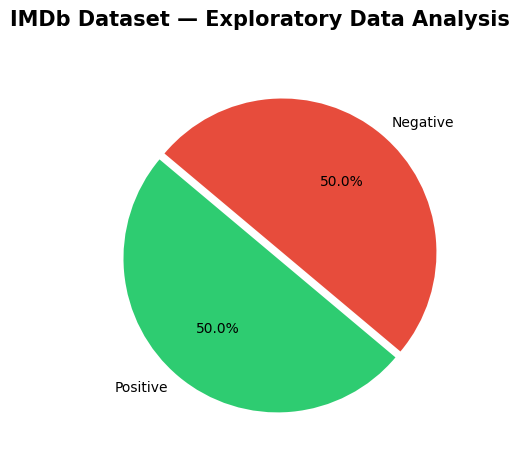

In [5]:
label_counts = df['label'].value_counts()
print(label_counts)

fig, axis = plt.subplots(1, 1, figsize=(18, 5))
fig.suptitle('IMDb Dataset — Exploratory Data Analysis', fontsize=15, fontweight='bold')
colors = ['#2ecc71', '#e74c3c']
# axis[0].bar(label_counts.index, label_counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axis.pie(label_counts, 
            labels=['Positive', 'Negative'], 
            autopct='%1.1f%%', 
            startangle=140, 
            colors=colors, 
            explode=(0.05, 0))

## Length

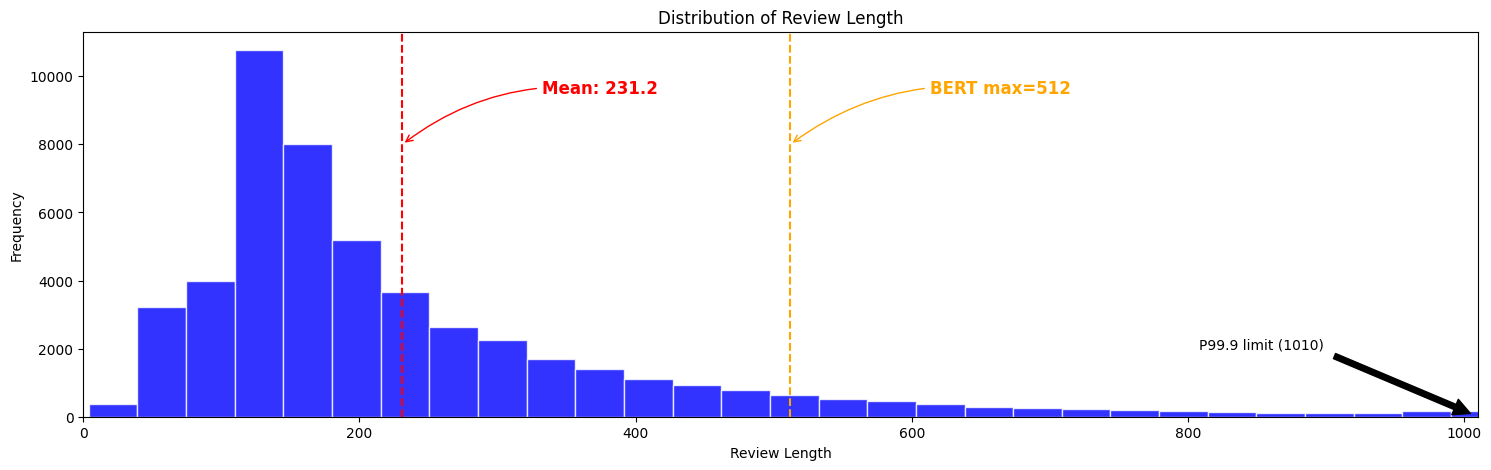

In [6]:
import seaborn as sns

df['review_length'] = df['text'].apply(lambda x: len(x.split()))
df.head()
fig, axes = plt.subplots(1, 1, figsize=(18, 5))
mean_val = df['review_length'].mean()
p999 = df['review_length'].quantile(0.999)

axes.hist(df['review_length'], bins=70, color='blue', alpha=0.8, edgecolor='white')
axes.axvline(df['review_length'].mean(), color='red', linestyle='--', label=f'Mean={mean_val:.0f}')
axes.annotate(
    f'Mean: {mean_val:.1f}', 
    xy=(mean_val, 8000),           
    xytext=(mean_val + p999*0.1, 9500), 
    fontsize=12, 
    fontweight='bold', 
    color='red',
    arrowprops=dict(
        arrowstyle="->",          
        connectionstyle="arc3,rad=.2",
        color='red'
    )
)
axes.axvline(512, color='orange', linestyle='--', label='BERT max=512')
axes.annotate(
    f'BERT max=512', 
    xy=(512, 8000),           
    xytext=(512 + p999*0.1, 9500), 
    fontsize=12, 
    fontweight='bold', 
    color='orange',
    arrowprops=dict(
        arrowstyle="->",          
        connectionstyle="arc3,rad=.2",
        color='orange'
    )
)
axes.set_title('Distribution of Review Length')
axes.set_xlabel('Review Length')
axes.set_ylabel('Frequency')

axes.set_xlim(0, p999)
axes.annotate(f'P99.9 limit ({p999:.0f})', 
                 xy=(p999, 0), xytext=(p999*0.8, 2000),
                 arrowprops=dict(facecolor='black', shrink=0.05))

fig.show()

# Plot 3: Reviews > 512 tokens

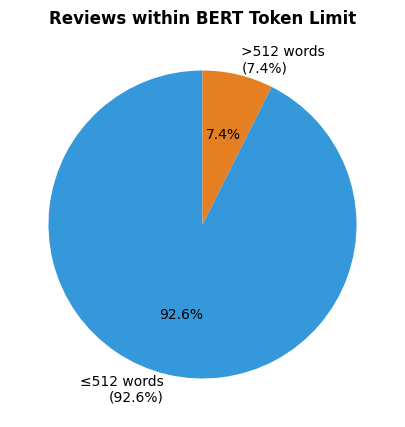


 Review length stats:
count    50000.0
mean       231.2
std        171.3
min          4.0
25%        126.0
50%        173.0
75%        280.0
max       2470.0
Name: review_length, dtype: float64


In [7]:
over_512 = (df['review_length'] > 512).sum()
fig, axes = plt.subplots(1, 1, figsize=(18, 5))
within_512 = len(df) - over_512
axes.pie([within_512, over_512],
            labels=[f'≤512 words\n({within_512/len(df)*100:.1f}%)', f'>512 words\n({over_512/len(df)*100:.1f}%)'],
            colors=['#3498db', '#e67e22'], autopct='%1.1f%%', startangle=90)
axes.set_title('Reviews within BERT Token Limit', fontweight='bold')

# plt.tight_layout()
# plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Review length stats:')
print(df['review_length'].describe().round(1))


## wordcloud

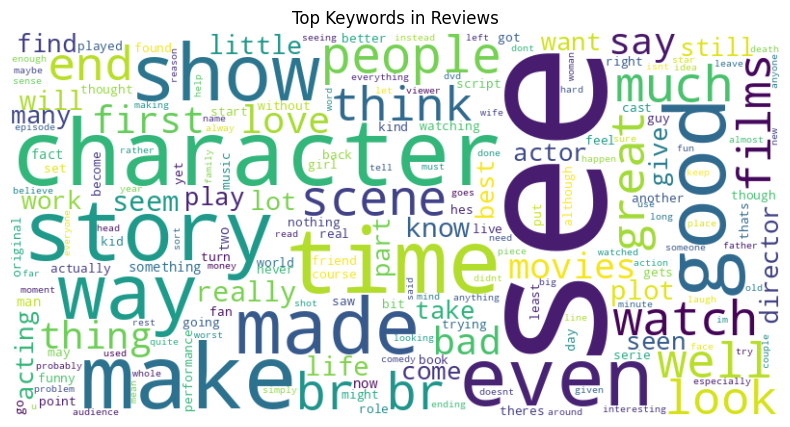

In [8]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re

all_text = ' '.join(df['text'].str.lower())
cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', '', all_text)

stopwords = set(STOPWORDS)
stopwords.update(["movie", "film", "one", "like"])

wc = WordCloud(
    background_color='white',
    max_words=200,
    stopwords=stopwords,
    width=800,
    height=400
)

wc.generate(cleaned_text)
fig, axes = plt.subplots(1, 1, figsize=(18, 5))

axes.imshow(wc, interpolation='bilinear')
axes.axis('off')
axes.set_title('Top Keywords in Reviews', fontsize=12)

#plt.tight_layout()
plt.show()

# 3. Network

# 3.1 Transformer(BERT)

### 3.1.1. Data Preprocessing & Tokenization

In [9]:
import re

def clean_text(text: str) -> str:
    """Remove HTML tags, separate punctuation, and normalize whitespace."""
    text = str(text).lower() 
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'([!?.,\'"\-])', r' \1 ', text)
    text = re.sub(r'[^a-z\s!?.,\'"\-]', '', text)  
    text = re.sub(r'\s+', ' ', text).strip()     
    
    return text

df['clean_review'] = df['text'].apply(clean_text).fillna('')
print(df['clean_review'].head())

0    i rented i am curious - yellow from my video s...
1    " i am curious yellow " is a risible and prete...
2    if only to avoid making this type of film in t...
3    this film was probably inspired by godard ' s ...
4    oh , brother . . . after hearing about this ri...
Name: clean_review, dtype: object


In [10]:
print('Sample cleaned review:')
print('-' * 60)
print('Original :', df['text'].iloc[0][:512])
print('Cleaned  :', df['clean_review'].iloc[0][:512])
print('-' * 60)
print(f'Label mapping: positive=1, negative=0')

Sample cleaned review:
------------------------------------------------------------
Original : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to maki
Cleaned  : i rented i am curious - yellow from my video store because of all the controversy that surrounded it when it was first released in . i also heard that at first it was seized by u . s . customs if it ever tried to enter this country , therefore being a fan of films considered " controversial " i really had to see this for myself . the plot is centered around a young swedish drama

### 3.1.2. Tokenizer

In [11]:
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 512

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)


2026-03-24 02:25:10.246811: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774319110.465223      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774319110.536346      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774319111.093140      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774319111.093181      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774319111.093184      24 computation_placer.cc:177] computation placer alr

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [12]:
sample = 'i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in . i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" i really had to see this for myself.the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life. in particular she wants to focus her attentions to making some sort of'
encoded = tokenizer(sample, max_length=MAX_LEN, padding="max_length", truncation=True, return_tensors='pt')
print(encoded)


{'input_ids': tensor([[  101,  1045, 12524,  1045,  2572,  8025,  1011,  3756,  2013,  2026,
          2678,  3573,  2138,  1997,  2035,  1996,  6704,  2008,  5129,  2009,
          2043,  2009,  2001,  2034,  2207,  1999,  1012,  1045,  2036,  2657,
          2008,  2012,  2034,  2009,  2001,  8243,  2011,  1057,  1012,  1055,
          1012,  8205,  2065,  2009,  2412,  2699,  2000,  4607,  2023,  2406,
          1010,  3568,  2108,  1037,  5470,  1997,  3152,  2641,  1000,  6801,
          1000,  1045,  2428,  2018,  2000,  2156,  2023,  2005,  2870,  1012,
          1996,  5436,  2003,  8857,  2105,  1037,  2402,  4467,  3689,  3076,
          2315, 14229,  2040,  4122,  2000,  4553,  2673,  2016,  2064,  2055,
          2166,  1012,  1999,  3327,  2016,  4122,  2000,  3579,  2014,  3086,
          2015,  2000,  2437,  2070,  4066,  1997,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,  

In [13]:
tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
non_pad = [t for t in tokens if t != '[PAD]']

print(f' Tokenizer loaded: {MODEL_NAME}')
print(f'   Vocab size       : {tokenizer.vocab_size:,}')
print(f'   Max sequence len : {MAX_LEN}')
print(f'\nSample tokenization:')
print(f'   Input    : "{sample}"')
print(f'   Tokens   : {non_pad}')
print(f'   Input IDs shape  : {encoded["input_ids"].shape}')
print(f'   Attention mask   : {encoded["attention_mask"][0][:len(non_pad)].tolist()}')

 Tokenizer loaded: bert-base-uncased
   Vocab size       : 30,522
   Max sequence len : 512

Sample tokenization:
   Input    : "i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in . i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" i really had to see this for myself.the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life. in particular she wants to focus her attentions to making some sort of"
   Tokens   : ['[CLS]', 'i', 'rented', 'i', 'am', 'curious', '-', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', '.', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized', 'by', 'u', '.', 's', '.', 'customs', 'if', 'it', 'ever'

### 3.1.3 PyTorch Dataset & DataLoaders

In [14]:
import torch
from torch.utils.data import Dataset
import pandas as pd
from transformers import BertTokenizer

class IMDbDataset(Dataset):
    def __init__(self, reviews: pd.Series, labels: pd.Series, tokenizer: BertTokenizer, max_len: int = 512):
        self.reviews = reviews.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.reviews)

    def __getitem__(self, idx: int) -> dict:
        review = str(self.reviews[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
        )
        
        return {
            'input_ids': torch.tensor(encoding['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(encoding['attention_mask'], dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [15]:
# df_sample = df.sample(n=1_000, random_state=SEED).reset_index(drop=True)
# df_sample.head()
df_sample = df
X_train, X_temp, y_train, y_temp = train_test_split(df_sample['clean_review'], df_sample['label'], test_size=0.2, random_state=SEED, stratify=df_sample['label'])
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)
print(f'Split sizes → Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')


Split sizes → Train: 40,000 | Val: 5,000 | Test: 5,000


In [16]:
BATCH_SIZE = 16
train_dataset = IMDbDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = IMDbDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = IMDbDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Verify a batch
batch = next(iter(train_loader))
print(f'\nBatch shapes:')
print(f'  input_ids      : {batch["input_ids"].shape}')
print(f'  attention_mask : {batch["attention_mask"].shape}')
print(f'  labels         : {batch["labels"].shape}')



Batch shapes:
  input_ids      : torch.Size([16, 512])
  attention_mask : torch.Size([16, 512])
  labels         : torch.Size([16])


### 3.1.4. Transformer

In [17]:
# ── Load Pre-trained BERT ─────────────────────────────────────────────────────
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
model = model.to(device)

# Model summary
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f' Model loaded: {MODEL_NAME}')
print(f'   Total parameters    : {total_params:,}')
print(f'   Trainable parameters: {trainable_params:,}')
print(f'   Architecture        : {model.config.architectures}')
print(f'   Hidden size         : {model.config.hidden_size}')
print(f'   Num attention heads : {model.config.num_attention_heads}')
print(f'   Num hidden layers   : {model.config.num_hidden_layers}')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Model loaded: bert-base-uncased
   Total parameters    : 109,483,778
   Trainable parameters: 109,483,778
   Architecture        : ['BertForMaskedLM']
   Hidden size         : 768
   Num attention heads : 12
   Num hidden layers   : 12


In [18]:
# ── Optimizer & Scheduler ─────────────────────────────────────────────────────
EPOCHS       = 3
LR           = 2e-5     # Standard BERT fine-tuning range: 2e-5 to 5e-5
WARMUP_RATIO = 0.1

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

# AdamW with weight decay (exclude bias and LayerNorm)
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
     'weight_decay': 0.01},
    {'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0}
]

optimizer = AdamW(optimizer_grouped_parameters, lr=LR, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Optimizer : AdamW (lr={LR}, weight_decay=0.01)')
print(f'Scheduler : Linear warmup + decay')
print(f'Epochs    : {EPOCHS}')
print(f'Total steps  : {total_steps:,}')
print(f'Warmup steps : {warmup_steps:,}')


Optimizer : AdamW (lr=2e-05, weight_decay=0.01)
Scheduler : Linear warmup + decay
Epochs    : 3
Total steps  : 7,500
Warmup steps : 750


### 3.1.5. Training Loop

In [19]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """Run one training epoch. Returns avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss   = outputs.loss
        logits = outputs.logits

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (step + 1) % 100 == 0:
            print(f'   Step [{step+1}/{len(loader)}] | loss: {total_loss/(step+1):.4f}')

    return total_loss / len(loader), correct / total

In [20]:
def evaluate(model, loader, device):
    """Evaluate model. Returns avg loss, accuracy, and predictions."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss   = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            preds       = torch.argmax(logits, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)
    

In [21]:
# ── Main Training Loop ────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_f1   = 0.0
best_model_path = 'best_bert_model.pt'

print('=' * 65)
print('           BERT FINE-TUNING — TRAINING START')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    print(f'\n Epoch {epoch}/{EPOCHS}')
    print('-' * 45)

    # ── Training ──
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)

    # ── Validation ──
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, device)
    val_f1 = f1_score(val_labels, val_preds, average='weighted')

    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'\n   Epoch time  : {elapsed/60:.1f} min')
    print(f'  Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f}')
    print(f'  Val   → Loss: {val_loss:.4f}  | Acc: {val_acc:.4f} | F1: {val_f1:.4f}')

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f'  Best model saved (val F1: {best_val_f1:.4f})')

print('\n' + '=' * 65)
print(f'  Training complete! Best Val F1: {best_val_f1:.4f}')
print('=' * 65)

           BERT FINE-TUNING — TRAINING START

 Epoch 1/3
---------------------------------------------
   Step [100/2500] | loss: 0.6853
   Step [200/2500] | loss: 0.6120
   Step [300/2500] | loss: 0.5237
   Step [400/2500] | loss: 0.4651
   Step [500/2500] | loss: 0.4208
   Step [600/2500] | loss: 0.3918
   Step [700/2500] | loss: 0.3728
   Step [800/2500] | loss: 0.3576
   Step [900/2500] | loss: 0.3441
   Step [1000/2500] | loss: 0.3325
   Step [1100/2500] | loss: 0.3239
   Step [1200/2500] | loss: 0.3157
   Step [1300/2500] | loss: 0.3097
   Step [1400/2500] | loss: 0.3032
   Step [1500/2500] | loss: 0.2997
   Step [1600/2500] | loss: 0.2952
   Step [1700/2500] | loss: 0.2902
   Step [1800/2500] | loss: 0.2873
   Step [1900/2500] | loss: 0.2843
   Step [2000/2500] | loss: 0.2802
   Step [2100/2500] | loss: 0.2772
   Step [2200/2500] | loss: 0.2731
   Step [2300/2500] | loss: 0.2708
   Step [2400/2500] | loss: 0.2685
   Step [2500/2500] | loss: 0.2669

   Epoch time  : 74.7 min
  Tr

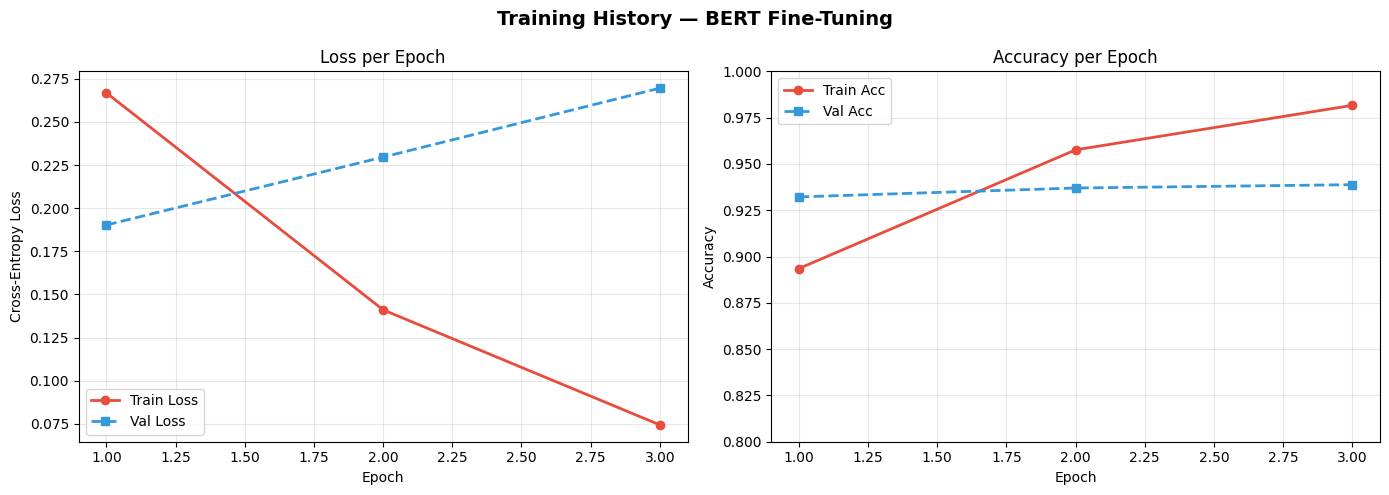

In [22]:
# ── Training Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — BERT Fine-Tuning', fontsize=14, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   's--', label='Val Loss',   color='#3498db', linewidth=2)
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train Acc', color='#e74c3c', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   's--', label='Val Acc',   color='#3498db', linewidth=2)
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0.8, 1.0])
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2. RNN

### 3.2.1. Tokenizer

In [23]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!mkdir glove_data
!unzip glove.6B.zip -d glove_data

--2026-03-24 06:10:16--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-24 06:10:16--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-24 06:10:16--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [24]:
import numpy as np
import torch
import torch.nn as nn

def load_glove_embeddings(file_path):
    print("Đang tải GloVe embeddings...")
    embeddings_dict = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings_dict[word] = vector
    print(f"Đã tải xong {len(embeddings_dict)} từ vựng từ GloVe.")
    return embeddings_dict

glove_path = 'glove_data/glove.6B.100d.txt' 
glove_dict = load_glove_embeddings(glove_path)

# Ví dụ: word2idx = {"<pad>": 0, "<unk>": 1, "movie": 2, "good": 3, ...}
sentences = df['clean_review'].tolist()

vocab = set()
for s in sentences:
    vocab.update(s.split())
    
print(f"len vocab: {len(vocab)}")
word2idx = {"<pad>": 0, "<unk>": 1}
idx = 2
for word in vocab:
    word2idx[word] = idx
    idx += 1

vocab_size = len(word2idx) 
print(f"Kích thước tập từ vựng thực tế (bao gồm pad và unk): {vocab_size}")

vocab_size = len(word2idx)
embedding_dim = 100

embedding_matrix = np.zeros((vocab_size, embedding_dim))

words_found = 0
for word, idx in word2idx.items():
    vector = glove_dict.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
        words_found += 1
    else:
        pass

print(f"Tỉ lệ từ vựng có trong GloVe: {words_found / vocab_size * 100:.2f}%")

embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)
embedding_layer = nn.Embedding.from_pretrained(embedding_tensor, freeze=False)

embedding_layer.padding_idx = 0

Đang tải GloVe embeddings...
Đã tải xong 400000 từ vựng từ GloVe.
len vocab: 111796
Kích thước tập từ vựng thực tế (bao gồm pad và unk): 111798
Tỉ lệ từ vựng có trong GloVe: 66.40%


### 3.2.2. Dataloader

In [25]:
class IMDBDatasetForRNN:
    def __init__(self, reviews, targets):
        """
        Argument:
        reviews: a numpy array
        targets: a vector array
        
        Return xtrain and ylabel in torch tensor datatype, stored in dictionary format
        """
        self.reviews = reviews
        self.target = targets
    
    def __len__(self):
        # return length of dataset
        return len(self.reviews)
    
    def __getitem__(self, index):
        # given an idex (item), return review and target of that index in torch tensor
        review = torch.tensor(self.reviews[index,:], dtype = torch.long)
        target = torch.tensor(self.target[index], dtype = torch.float)
        
        return {
                'review': review,
                'label': target
            }


In [26]:
import numpy as np
from torch.utils.data import DataLoader

def texts_to_padded_matrix(texts, word2idx, max_len=256):
    """Chuyển list text thành ma trận numpy 2D (num_samples, max_len)"""
    matrix = []
    for text in texts:
        tokens = str(text).split()
        seq = [word2idx.get(word, 1) for word in tokens]
        
        if len(seq) < max_len:
            seq = seq + [0] * (max_len - len(seq)) # 0 là <pad>
        else:
            seq = seq[:max_len]
            
        matrix.append(seq)
    return np.array(matrix)

MAX_LEN_LSTM = 256
from sklearn.model_selection import train_test_split

X = df['clean_review']
y = df['label'] 

X_train_clean, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

X_val_clean, X_test_clean, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"✅ Đã tạo xong các tập dữ liệu!")
print(f"  - Tập Train: {X_train_clean.shape[0]} câu")
print(f"  - Tập Val  : {X_val_clean.shape[0]} câu")
print(f"  - Tập Test : {X_test_clean.shape[0]} câu")

X_train_seq = texts_to_padded_matrix(X_train_clean, word2idx, MAX_LEN_LSTM)
X_val_seq   = texts_to_padded_matrix(X_val_clean,   word2idx, MAX_LEN_LSTM)
X_test_seq  = texts_to_padded_matrix(X_test_clean,  word2idx, MAX_LEN_LSTM)

y_train_arr = np.array(y_train)
y_val_arr   = np.array(y_val)
y_test_arr  = np.array(y_test)

train_dataset_lstm = IMDBDatasetForRNN(X_train_seq, y_train_arr)
val_dataset_lstm   = IMDBDatasetForRNN(X_val_seq,   y_val_arr)
test_dataset_lstm  = IMDBDatasetForRNN(X_test_seq,  y_test_arr)

BATCH_SIZE = 16
train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_lstm   = DataLoader(val_dataset_lstm,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_lstm  = DataLoader(test_dataset_lstm,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

batch_lstm = next(iter(train_loader_lstm))
print('\n--- LSTM BATCH SHAPES ---')
print(f'  review : {batch_lstm["review"].shape}')
print(f'  label  : {batch_lstm["label"].shape}')

✅ Đã tạo xong các tập dữ liệu!
  - Tập Train: 40000 câu
  - Tập Val  : 5000 câu
  - Tập Test : 5000 câu

--- LSTM BATCH SHAPES ---
  review : torch.Size([16, 256])
  label  : torch.Size([16])


### 3.2.3. RNN

In [27]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix):
        """
        Given embedding_matrix: numpy array with vector for all words
        return prediction (in torch tensor format)
        """
        super(LSTMClassifier, self).__init__()
        
        embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=True)
        
        embedding_dim = embedding_matrix.shape[1]
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim, 
            hidden_size=128,
            bidirectional=True,
            batch_first=True,
        )
        
        self.dropout = nn.Dropout(0.3)
        
        # 4. Input(512) vì Bi-LSTM (128*2) + Concat Max/Avg Pooling (*2) = 512
        self.out = nn.Linear(512, 1)

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        x = self.embedding(x)
        
        lstm_out, _ = self.lstm(x)
        # lstm_out shape: [batch_size, seq_len, 256]
        
        # Áp dụng Average Pooling và Max Pooling dọc theo chiều seq_len (dim=1)
        avg_pool = torch.mean(lstm_out, dim=1)
        max_pool, _ = torch.max(lstm_out, dim=1)
        
        out = torch.cat((avg_pool, max_pool), dim=1)
        # out shape: [batch_size, 512]
        
        # Đi qua Dropout rồi vào Linear Layer
        out = self.dropout(out)
        out = self.out(out)
        
        return out

In [28]:
import torch
import torch.nn as nn

def train_epoch_lstm(model, loader, optimizer, criterion, device, scheduler=None):
    """Run one training epoch for LSTM. Returns avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for step, batch in enumerate(loader):
        input_ids = batch['review'].to(device)
        labels = batch['label'].to(device) 

        optimizer.zero_grad()

        # 2. Forward pass: LSTM trả về tensor output shape [batch_size, 1]
        logits = model(input_ids)

        # 3. Tính loss: BCEWithLogitsLoss yêu cầu labels phải là float và cùng shape với logits
        # squeeze/unsqueeze giúp đảm bảo labels có shape [batch_size, 1]
        loss = criterion(logits, labels.float().unsqueeze(1))

        loss.backward()
        
        # Gradient clipping vẫn rất tốt cho LSTM để tránh exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        
        optimizer.step()
        
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        
        # 4. Tính Accuracy cho Binary Classification (1 output node)
        # Vì ta dùng BCEWithLogitsLoss (chưa đi qua Sigmoid), ngưỡng phân chia class là 0.0
        # (Nếu logits >= 0.0 thì xác suất >= 0.5 -> class 1, ngược lại -> class 0)
        preds = (logits >= 0.0).long()
        
        correct += (preds == labels.unsqueeze(1)).sum().item()
        total   += labels.size(0)

        if (step + 1) % 100 == 0:
            print(f'   Step [{step+1}/{len(loader)}] | loss: {total_loss/(step+1):.4f}')

    return total_loss / len(loader), correct / total

In [29]:
def evaluate_lstm(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['review'].to(device)
            labels    = batch['label'].to(device)

            logits = model(input_ids)

            loss = criterion(logits, labels.float().unsqueeze(1))
            total_loss += loss.item()

            preds = (logits >= 0.0).long()
            correct += (preds == labels.unsqueeze(1)).sum().item()
            total   += labels.size(0)

            all_preds.extend(preds.squeeze(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)

In [30]:
import time
import torch
import torch.nn as nn
from sklearn.metrics import f1_score

rnn_model = LSTMClassifier(embedding_matrix).to(device)
# criterion cho bài toán Binary Classification với 1 output node
criterion = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=1e-3)

# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
scheduler = None 

EPOCHS = 100

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_f1   = 0.0
best_model_path = 'best_lstm_model.pt'

print('=' * 65)
print('           LSTM TEXT CLASSIFICATION — TRAINING START')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    print(f'\n Epoch {epoch}/{EPOCHS}')
    print('-' * 45)

    # ── Training ──
    train_loss, train_acc = train_epoch_lstm(rnn_model, train_loader_lstm, optimizer, criterion, device, scheduler)

    # ── Validation ──
    val_loss, val_acc, val_preds, val_labels = evaluate_lstm(rnn_model, val_loader_lstm, criterion, device)
    
    val_f1 = f1_score(val_labels, val_preds, average='weighted')

    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'\n   Epoch time  : {elapsed/60:.1f} min')
    print(f'  Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f}')
    print(f'  Val   → Loss: {val_loss:.4f}  | Acc: {val_acc:.4f} | F1: {val_f1:.4f}')

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(rnn_model.state_dict(), best_model_path)
        print(f'  Best model saved (val F1: {best_val_f1:.4f})')

print('\n' + '=' * 65)
print(f'  Training complete! Best Val F1: {best_val_f1:.4f}')
print('=' * 65)

           LSTM TEXT CLASSIFICATION — TRAINING START

 Epoch 1/100
---------------------------------------------
   Step [100/2500] | loss: 0.6856
   Step [200/2500] | loss: 0.6636
   Step [300/2500] | loss: 0.6255
   Step [400/2500] | loss: 0.5909
   Step [500/2500] | loss: 0.5633
   Step [600/2500] | loss: 0.5421
   Step [700/2500] | loss: 0.5237
   Step [800/2500] | loss: 0.5075
   Step [900/2500] | loss: 0.4943
   Step [1000/2500] | loss: 0.4844
   Step [1100/2500] | loss: 0.4746
   Step [1200/2500] | loss: 0.4668
   Step [1300/2500] | loss: 0.4586
   Step [1400/2500] | loss: 0.4536
   Step [1500/2500] | loss: 0.4478
   Step [1600/2500] | loss: 0.4434
   Step [1700/2500] | loss: 0.4379
   Step [1800/2500] | loss: 0.4332
   Step [1900/2500] | loss: 0.4283
   Step [2000/2500] | loss: 0.4244
   Step [2100/2500] | loss: 0.4207
   Step [2200/2500] | loss: 0.4176
   Step [2300/2500] | loss: 0.4138
   Step [2400/2500] | loss: 0.4105
   Step [2500/2500] | loss: 0.4079

   Epoch time  : 0.3

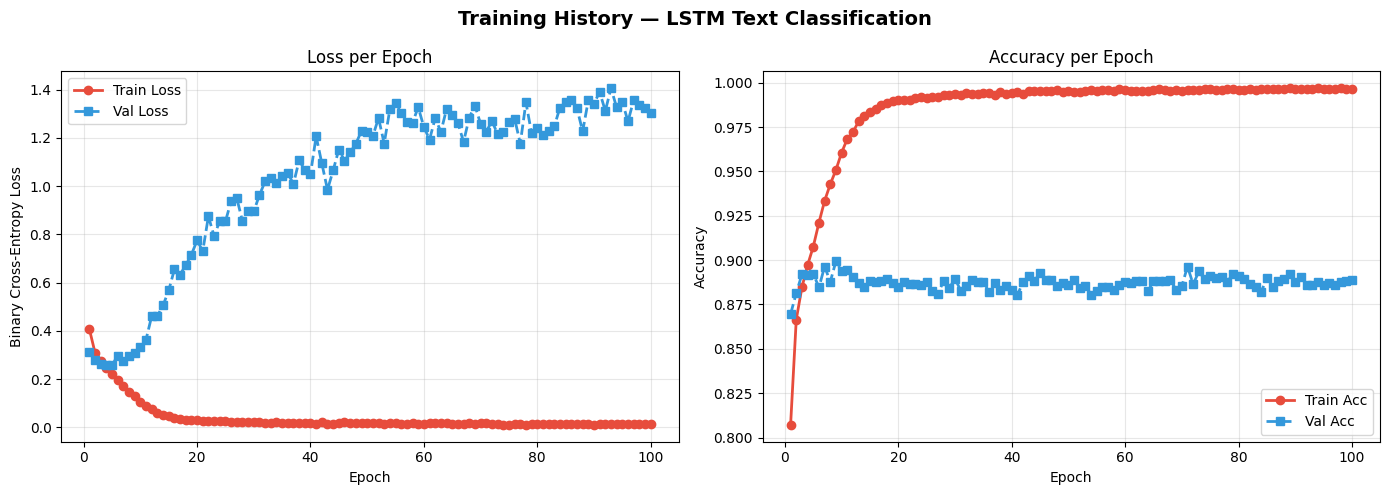

In [31]:
import matplotlib.pyplot as plt

# ── Training Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — LSTM Text Classification', fontsize=14, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

# --- Biểu đồ Loss ---
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   's--', label='Val Loss',   color='#3498db', linewidth=2)
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Biểu đồ Accuracy ---
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train Acc', color='#e74c3c', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   's--', label='Val Acc',   color='#3498db', linewidth=2)
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

# axes[1].set_ylim([0.5, 1.0])
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Evaluation — Accuracy, F1 Score & Confusion Matrix

                 BERT - TEST SET EVALUATION
  Loss          : 0.2511
  Accuracy      : 0.9432  (94.32%)
  F1 (weighted) : 0.9432
  F1 (macro)    : 0.9432
------------------------------------------------------------
 Classification Report (BERT):
              precision    recall  f1-score   support

    Negative       0.95      0.93      0.94      2500
    Positive       0.93      0.95      0.94      2500

    accuracy                           0.94      5000
   macro avg       0.94      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000



                 LSTM - TEST SET EVALUATION
  Loss          : 0.3089
  Accuracy      : 0.8950  (89.50%)
  F1 (weighted) : 0.8950
  F1 (macro)    : 0.8950
------------------------------------------------------------
 Classification Report (LSTM):
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90      2535
    Positive       0.89      0.90      0.89      2465

    accuracy   

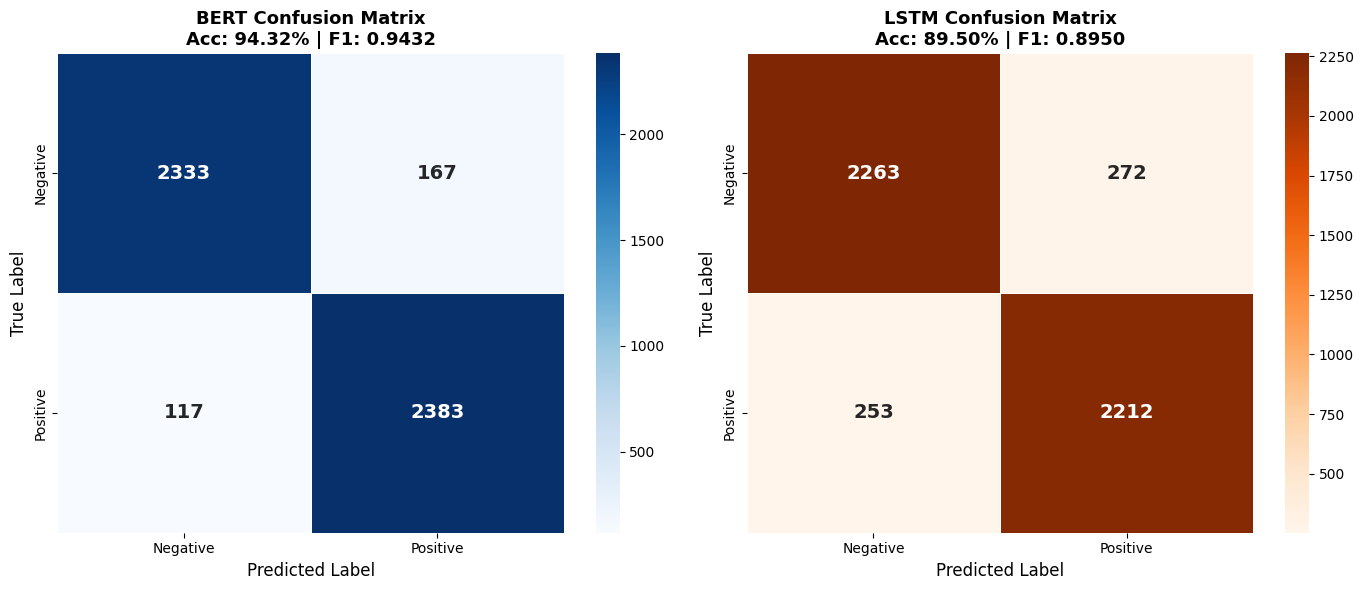


 CHI TIẾT DỰ ĐOÁN (True/False Positives & Negatives)
BERT:
  True Negatives : 2333  | False Positives: 167
  False Negatives: 117   | True Positives : 2383

LSTM:
  True Negatives : 2263  | False Positives: 272
  False Negatives: 253   | True Positives : 2212


In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# =============================================================================
# 1. ĐÁNH GIÁ MÔ HÌNH BERT
# =============================================================================
print('=' * 60)
print('                 BERT - TEST SET EVALUATION')
print('=' * 60)

# Load best BERT model (Giả sử model_bert đã được khởi tạo)
model.load_state_dict(torch.load('best_bert_model.pt', map_location=device))

# Gọi hàm evaluate của BERT
test_loss_b, test_acc_b, test_preds_b, test_labels_b = evaluate(model, test_loader, device)

test_f1_b       = f1_score(test_labels_b, test_preds_b, average='weighted')
test_f1_macro_b = f1_score(test_labels_b, test_preds_b, average='macro')

print(f'  Loss          : {test_loss_b:.4f}')
print(f'  Accuracy      : {test_acc_b:.4f}  ({test_acc_b*100:.2f}%)')
print(f'  F1 (weighted) : {test_f1_b:.4f}')
print(f'  F1 (macro)    : {test_f1_macro_b:.4f}')
print('-' * 60)
print(' Classification Report (BERT):')
print(classification_report(test_labels_b, test_preds_b, target_names=['Negative', 'Positive']))


# =============================================================================
# 2. ĐÁNH GIÁ MÔ HÌNH LSTM
# =============================================================================
print('\n\n' + '=' * 60)
print('                 LSTM - TEST SET EVALUATION')
print('=' * 60)

# Load best LSTM model
rnn_model.load_state_dict(torch.load('best_lstm_model.pt', map_location=device))

# Tiêu chí Loss cho LSTM
criterion = nn.BCEWithLogitsLoss()

# Gọi hàm evaluate_lstm
test_loss_l, test_acc_l, test_preds_l, test_labels_l = evaluate_lstm(rnn_model, test_loader_lstm, criterion, device)

test_f1_l       = f1_score(test_labels_l, test_preds_l, average='weighted')
test_f1_macro_l = f1_score(test_labels_l, test_preds_l, average='macro')

print(f'  Loss          : {test_loss_l:.4f}')
print(f'  Accuracy      : {test_acc_l:.4f}  ({test_acc_l*100:.2f}%)')
print(f'  F1 (weighted) : {test_f1_l:.4f}')
print(f'  F1 (macro)    : {test_f1_macro_l:.4f}')
print('-' * 60)
print(' Classification Report (LSTM):')
print(classification_report(test_labels_l, test_preds_l, target_names=['Negative', 'Positive']))


# =============================================================================
# 3. VẼ CONFUSION MATRIX SO SÁNH (SIDE-BY-SIDE)
# =============================================================================
cm_bert = confusion_matrix(test_labels_b, test_preds_b)
cm_lstm = confusion_matrix(test_labels_l, test_preds_l)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot BERT ---
sns.heatmap(
    cm_bert, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'],
    linewidths=0.5, linecolor='white', ax=axes[0],
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title(f'BERT Confusion Matrix\nAcc: {test_acc_b*100:.2f}% | F1: {test_f1_b:.4f}', 
                  fontsize=13, fontweight='bold')

# --- Plot LSTM ---
sns.heatmap(
    cm_lstm, annot=True, fmt='d', cmap='Oranges', # Đổi màu Oranges cho dễ phân biệt
    xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'],
    linewidths=0.5, linecolor='white', ax=axes[1],
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title(f'LSTM Confusion Matrix\nAcc: {test_acc_l*100:.2f}% | F1: {test_f1_l:.4f}', 
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# --- In chi tiết True/False Positives/Negatives ---
print('\n' + '=' * 60)
print(' CHI TIẾT DỰ ĐOÁN (True/False Positives & Negatives)')
print('=' * 60)

tn_b, fp_b, fn_b, tp_b = cm_bert.ravel()
print('BERT:')
print(f'  True Negatives : {tn_b:<5} | False Positives: {fp_b}')
print(f'  False Negatives: {fn_b:<5} | True Positives : {tp_b}')

tn_l, fp_l, fn_l, tp_l = cm_lstm.ravel()
print('\nLSTM:')
print(f'  True Negatives : {tn_l:<5} | False Positives: {fp_l}')
print(f'  False Negatives: {fn_l:<5} | True Positives : {tp_l}')
print('=' * 60)

# 8. Inference on Custom Text

In [33]:
# ── Inference Pipeline ────────────────────────────────────────────────────────
def predict_sentiment(texts: list, model, tokenizer, device, max_len=256) -> list:
    """
    Predict sentiment for a list of review texts.
    Returns a list of dicts with label, confidence, and probabilities.
    """
    model.eval()
    results = []

    for text in texts:
        text_clean = clean_text(text)
        encoding   = tokenizer(
            text_clean,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

        pred_label = 'POSITIVE' if probs[1] > probs[0] else 'NEGATIVE'
        confidence = max(probs)

        results.append({
            'text'           : text[:80] + '...' if len(text) > 80 else text,
            'sentiment'      : pred_label,
            'confidence'     : f'{confidence*100:.1f}%',
            'prob_negative'  : f'{probs[0]*100:.1f}%',
            'prob_positive'  : f'{probs[1]*100:.1f}%',
        })

    return results


# ── Test Samples ─────────────────────────────────────────────────────────────
test_reviews = [
    "An absolute masterpiece. The cinematography is stunning, the performances are breathtaking, "
    "and the story moved me to tears. One of the best films I've ever seen!",

    "What a complete waste of time and money. The plot made no sense, the acting was wooden, "
    "and I fell asleep halfway through. I want those two hours back.",

    "It was okay, nothing special. Some scenes were interesting but the pacing felt off. "
    "Probably wouldn't watch it again.",

    "Nolan has done it again! Interstellar is a mind-bending journey that challenges your perception "
    "of time and space. A visual spectacle backed by a powerful Hans Zimmer score.",

    "Terrible CGI, predictable storyline, and a lead performance that felt completely flat. "
    "How did this get greenlit?"
]

predictions = predict_sentiment(test_reviews, model, tokenizer, device)

print('SENTIMENT PREDICTIONS')
print('=' * 75)
for i, pred in enumerate(predictions, 1):
    icon = '🟢' if pred['sentiment'] == 'POSITIVE' else '🔴'
    print(f"{i}. {icon} [{pred['sentiment']}] Confidence: {pred['confidence']}")
    print(f"   Text   : {pred['text']}")
    print(f"   P(neg) : {pred['prob_negative']} | P(pos): {pred['prob_positive']}")
    print()

# Display as DataFrame
pd.DataFrame(predictions)

SENTIMENT PREDICTIONS
1. 🟢 [POSITIVE] Confidence: 99.9%
   Text   : An absolute masterpiece. The cinematography is stunning, the performances are br...
   P(neg) : 0.1% | P(pos): 99.9%

2. 🔴 [NEGATIVE] Confidence: 99.9%
   Text   : What a complete waste of time and money. The plot made no sense, the acting was ...
   P(neg) : 99.9% | P(pos): 0.1%

3. 🔴 [NEGATIVE] Confidence: 99.8%
   Text   : It was okay, nothing special. Some scenes were interesting but the pacing felt o...
   P(neg) : 99.8% | P(pos): 0.2%

4. 🟢 [POSITIVE] Confidence: 99.9%
   Text   : Nolan has done it again! Interstellar is a mind-bending journey that challenges ...
   P(neg) : 0.1% | P(pos): 99.9%

5. 🔴 [NEGATIVE] Confidence: 100.0%
   Text   : Terrible CGI, predictable storyline, and a lead performance that felt completely...
   P(neg) : 100.0% | P(pos): 0.0%



,text,sentiment,confidence,prob_negative,prob_positive
0,An absolute masterpiece. The cinematography is...,POSITIVE,99.9%,0.1%,99.9%
1,What a complete waste of time and money. The p...,NEGATIVE,99.9%,99.9%,0.1%
2,"It was okay, nothing special. Some scenes were...",NEGATIVE,99.8%,99.8%,0.2%
3,Nolan has done it again! Interstellar is a min...,POSITIVE,99.9%,0.1%,99.9%
4,"Terrible CGI, predictable storyline, and a lea...",NEGATIVE,100.0%,100.0%,0.0%


In [34]:
import torch
import pandas as pd

# ── Inference Pipeline (Dành cho LSTM) ────────────────────────────────────────
def predict_sentiment_lstm(texts: list, model, word2idx, device, max_len=256) -> list:
    """
    Predict sentiment for a list of review texts using LSTM.
    Returns a list of dicts with label, confidence, and probabilities.
    """
    model.eval()
    results = []

    for text in texts:
        # 1. Làm sạch văn bản (dùng hàm clean_text đã có)
        text_clean = clean_text(text)
        
        # 2. Tokenize thủ công và chuyển thành mảng số nguyên
        tokens = text_clean.split()
        seq = [word2idx.get(word, 1) for word in tokens] # 1 là index của <unk>
        
        # 3. Padding / Truncation
        if len(seq) < max_len:
            seq = seq + [0] * (max_len - len(seq)) # 0 là <pad>
        else:
            seq = seq[:max_len]
            
        # 4. Chuyển thành Tensor và đưa lên GPU (thêm chiều batch_size = 1)
        input_ids = torch.tensor([seq], dtype=torch.long).to(device)

        with torch.no_grad():
            # 5. Đưa qua mô hình LSTM (Không có attention_mask, không có .logits)
            logits = model(input_ids)
            
            # 6. Tính xác suất bằng hàm Sigmoid
            prob_positive = torch.sigmoid(logits).item()
            prob_negative = 1.0 - prob_positive

        # 7. Phân loại nhãn và độ tự tin (ngưỡng 0.5)
        pred_label = 'POSITIVE' if prob_positive >= 0.5 else 'NEGATIVE'
        confidence = prob_positive if pred_label == 'POSITIVE' else prob_negative

        results.append({
            'text'           : text[:80] + '...' if len(text) > 80 else text,
            'sentiment'      : pred_label,
            'confidence'     : f'{confidence*100:.1f}%',
            'prob_negative'  : f'{prob_negative*100:.1f}%',
            'prob_positive'  : f'{prob_positive*100:.1f}%',
        })

    return results

# ── Test Samples ─────────────────────────────────────────────────────────────
test_reviews = [
    "An absolute masterpiece. The cinematography is stunning, the performances are breathtaking, "
    "and the story moved me to tears. One of the best films I've ever seen!",

    "What a complete waste of time and money. The plot made no sense, the acting was wooden, "
    "and I fell asleep halfway through. I want those two hours back.",

    "It was okay, nothing special. Some scenes were interesting but the pacing felt off. "
    "Probably wouldn't watch it again.",

    "Nolan has done it again! Interstellar is a mind-bending journey that challenges your perception "
    "of time and space. A visual spectacle backed by a powerful Hans Zimmer score.",

    "Terrible CGI, predictable storyline, and a lead performance that felt completely flat. "
    "How did this get greenlit?"
]

# Lưu ý: truyền `model_lstm` và `word2idx` vào hàm
predictions = predict_sentiment_lstm(test_reviews, rnn_model, word2idx, device)

print('LSTM SENTIMENT PREDICTIONS')
print('=' * 75)
for i, pred in enumerate(predictions, 1):
    icon = '🟢' if pred['sentiment'] == 'POSITIVE' else '🔴'
    print(f"{i}. {icon} [{pred['sentiment']}] Confidence: {pred['confidence']}")
    print(f"   Text   : {pred['text']}")
    print(f"   P(neg) : {pred['prob_negative']} | P(pos): {pred['prob_positive']}")
    print()

# Display as DataFrame (nếu bạn chạy trên Jupyter/Colab)
display(pd.DataFrame(predictions))

LSTM SENTIMENT PREDICTIONS
1. 🟢 [POSITIVE] Confidence: 100.0%
   Text   : An absolute masterpiece. The cinematography is stunning, the performances are br...
   P(neg) : 0.0% | P(pos): 100.0%

2. 🔴 [NEGATIVE] Confidence: 100.0%
   Text   : What a complete waste of time and money. The plot made no sense, the acting was ...
   P(neg) : 100.0% | P(pos): 0.0%

3. 🔴 [NEGATIVE] Confidence: 97.8%
   Text   : It was okay, nothing special. Some scenes were interesting but the pacing felt o...
   P(neg) : 97.8% | P(pos): 2.2%

4. 🟢 [POSITIVE] Confidence: 99.7%
   Text   : Nolan has done it again! Interstellar is a mind-bending journey that challenges ...
   P(neg) : 0.3% | P(pos): 99.7%

5. 🔴 [NEGATIVE] Confidence: 100.0%
   Text   : Terrible CGI, predictable storyline, and a lead performance that felt completely...
   P(neg) : 100.0% | P(pos): 0.0%



,text,sentiment,confidence,prob_negative,prob_positive
0,An absolute masterpiece. The cinematography is...,POSITIVE,100.0%,0.0%,100.0%
1,What a complete waste of time and money. The p...,NEGATIVE,100.0%,100.0%,0.0%
2,"It was okay, nothing special. Some scenes were...",NEGATIVE,97.8%,97.8%,2.2%
3,Nolan has done it again! Interstellar is a min...,POSITIVE,99.7%,0.3%,99.7%
4,"Terrible CGI, predictable storyline, and a lea...",NEGATIVE,100.0%,100.0%,0.0%


# 9. Results Summary

In [35]:
import pandas as pd

# ── Final Results Dashboard (So sánh BERT và LSTM) ───────────────────────────
results_data = {
    'Metric'      : ['Accuracy', 'F1 Score (Weighted)', 'F1 Score (Macro)', 'Test Loss'],
    'BERT Output' : [f'{test_acc_b*100:.2f}%', f'{test_f1_b:.4f}', f'{test_f1_macro_b:.4f}', f'{test_loss_b:.4f}'],
    'LSTM Output' : [f'{test_acc_l*100:.2f}%', f'{test_f1_l:.4f}', f'{test_f1_macro_l:.4f}', f'{test_loss_l:.4f}'],
    'Benchmark'   : ['> 88%', '> 0.88', '> 0.88', '—'],
    # Đánh giá dựa trên LSTM: Nếu Acc/F1 > 85% thì đạt (✅), ngược lại cảnh báo (⚠️)
    'Status'      : ['✅' if test_acc_l >= 0.85 else '⚠️'] * 1 +
                    ['✅' if test_f1_l >= 0.85 else '⚠️'] * 2 + ['✅']
}

results_df = pd.DataFrame(results_data)

print('\n' + '=' * 70)
print('                 FINAL MODEL PERFORMANCE COMPARISON')
print('=' * 70)
print(results_df.to_string(index=False))
print('=' * 70)

print(f"""
 EXPERIMENT CONFIGURATION
──────────────────────────────────────────────────────────────────────
 Dataset        : IMDb Reviews
 Max Seq Len    : BERT (512) | LSTM (256)
 Batch Size     : {BATCH_SIZE}
 Epochs         : BERT (Thường 3-4) | LSTM (10)
 Embeddings     : BERT (Pre-trained Transformers) | LSTM (GloVe 100d)
 Optimizer      : BERT (AdamW + Warmup) | LSTM (Adam)
 Device         : {device}
──────────────────────────────────────────────────────────────────────
""")


                 FINAL MODEL PERFORMANCE COMPARISON
             Metric BERT Output LSTM Output Benchmark Status
           Accuracy      94.32%      89.50%     > 88%      ✅
F1 Score (Weighted)      0.9432      0.8950    > 0.88      ✅
   F1 Score (Macro)      0.9432      0.8950    > 0.88      ✅
          Test Loss      0.2511      0.3089         —      ✅

 EXPERIMENT CONFIGURATION
──────────────────────────────────────────────────────────────────────
 Dataset        : IMDb Reviews
 Max Seq Len    : BERT (512) | LSTM (256)
 Batch Size     : 16
 Epochs         : BERT (Thường 3-4) | LSTM (10)
 Embeddings     : BERT (Pre-trained Transformers) | LSTM (GloVe 100d)
 Optimizer      : BERT (AdamW + Warmup) | LSTM (Adam)
 Device         : cuda
──────────────────────────────────────────────────────────────────────

